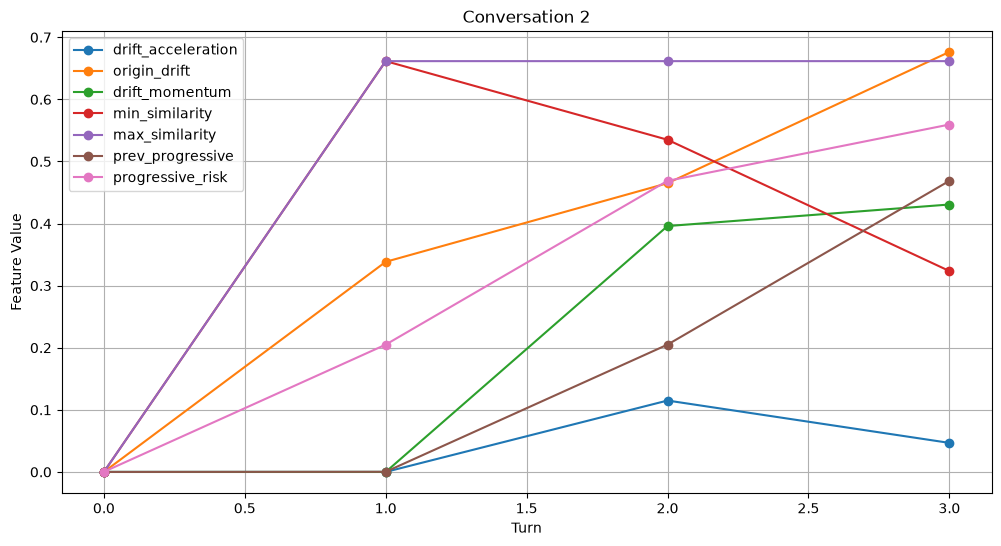

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/total/features_before_selection(5).csv")

conv_id = 2

conv = (
    df[df["conv_id"] == conv_id]
    .sort_values("turn_id")
)

features = [
    "drift_acceleration",
        "origin_drift",
        "drift_momentum",
        # "persistent_drift_count",
        "min_similarity",
        "max_similarity",
        "prev_progressive",
        "progressive_risk",
        # # "risk_slope_3",
        # "max_toxicity_so_far",
        # "mean_risk_so_far",
        # "late_risk_increase",
        # "risk_growth_ratio",
        # "trajectory_linearity"
        # "angular_coverage"
]

plt.figure(figsize=(12,6))

for feature in features:
    plt.plot(
        conv["turn_id"],
        conv[feature],
        marker="o",
        label=feature
    )

plt.xlabel("Turn")
plt.ylabel("Feature Value")
plt.title(f"Conversation {conv_id}")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

plot_df = conv[features]

scaler = MinMaxScaler()

scaled = pd.DataFrame(
    scaler.fit_transform(plot_df),
    columns=features
)

plt.figure(figsize=(14,7))

for feature in features:
    plt.plot(
        conv["turn_id"],
        scaled[feature],
        marker="o",
        linewidth=2,
        label=feature
    )

plt.xlabel("Turn")
plt.ylabel("Normalized Value")
plt.title("Feature Growth Through Conversation")
plt.grid(True)
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()